# E01: 
Tune the hyperparameters of the training to beat best validation loss of 2.2


## Solution:
Hyperparameter C's length changed from 10 to 20. 

Results:
- Validation loss: 2.1520
- Test loss: 2.1355

In [9]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [10]:
words = open('names.txt', 'r').read().splitlines()

In [11]:
len(words)

32033

In [12]:
random.shuffle(words)

In [13]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [26]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X).to(device)
  Y = torch.tensor(Y).to(device)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
Xte.device

torch.Size([182499, 3]) torch.Size([182499])
torch.Size([22903, 3]) torch.Size([22903])
torch.Size([22744, 3]) torch.Size([22744])


device(type='cuda', index=0)

In [57]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 20), generator=g).to(device)
W1 = torch.randn((60, 200), generator=g).to(device)
b1 = torch.randn(200, generator=g).to(device)
W2 = torch.randn((200, 27), generator=g).to(device)
b2 = torch.randn(27, generator=g).to(device)
parameters = [C, W1, b1, W2, b2]

In [58]:
num = sum(p.nelement() for p in parameters) # number of parameters in total
num

18167

In [59]:
for p in parameters:
  p.requires_grad = True

In [60]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [61]:
lri = []
lossi = []
stepi = []

In [62]:
k=0
for i in range(200000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 60) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])  
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    #lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        with torch.no_grad():
            p += -lr * p.grad
    
    # track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
    k+=1
    if k==1000:
        print(f"Loss at step {i} is {loss.item()}")
        k=0
print(loss.item())

Loss at step 999 is 3.525407075881958
Loss at step 1999 is 3.5842037200927734
Loss at step 2999 is 3.3229570388793945
Loss at step 3999 is 2.0376944541931152
Loss at step 4999 is 3.4319634437561035
Loss at step 5999 is 2.8800032138824463
Loss at step 6999 is 2.449098825454712
Loss at step 7999 is 2.1449756622314453
Loss at step 8999 is 1.7006382942199707
Loss at step 9999 is 2.8051540851593018
Loss at step 10999 is 2.1958272457122803
Loss at step 11999 is 2.7165908813476562
Loss at step 12999 is 3.102667808532715
Loss at step 13999 is 2.7511606216430664
Loss at step 14999 is 2.238621711730957
Loss at step 15999 is 2.139598846435547
Loss at step 16999 is 2.5950541496276855
Loss at step 17999 is 2.3798141479492188
Loss at step 18999 is 2.309668779373169
Loss at step 19999 is 2.2798755168914795
Loss at step 20999 is 1.886770486831665
Loss at step 21999 is 2.9160304069519043
Loss at step 22999 is 3.069110155105591
Loss at step 23999 is 1.871423602104187
Loss at step 24999 is 2.554832935333

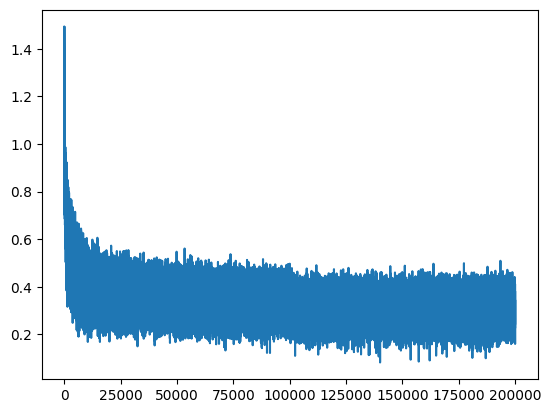

In [63]:
plt.plot(stepi, lossi)

In [65]:
# training loss
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 60) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0630, device='cuda:0', grad_fn=<NllLossBackward0>)

In [67]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 60) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1520, device='cuda:0', grad_fn=<NllLossBackward0>)

In [68]:
# test loss
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 60) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1355, device='cuda:0', grad_fn=<NllLossBackward0>)

In [73]:
# sample from the model
g = torch.Generator(device).manual_seed(214741364)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

evin.
nara.
achin.
kamera.
klana.
aver.
rheidh.
sanka.
eyr.
kami.
via.
yeah.
riden.
hadleige.
nason.
brooklina.
kasi.
ahav.
raj.
saiba.


# E02
I was not careful with the intialization of the network in this video. 
(1) What is the loss you'd get if the predicted probabilities at initialization were perfectly uniform? What loss do we achieve? 

Answer: If predicted probabilites at initialization were perfectly uniform then loss: -ln(1/27) = 3.295836866

(2) Can you tune the initialization to get a starting loss that is much more similar to (1)
Answer:

In [103]:
# z=[z1,z2,z3,z4]
# p = z.exp() / z.exp().sum()
# z = Wx + b
# if b = 0, then z = Wx
# if all values in W is very small (close to zero but not zero) eg W*0.0001 then z_i ~= x
# z1 = x
# z2 = x
# z3 = x
# z4 = x
# p = x/4x = 0.25 
# thus p = [0.25, 0.25, 0.25, 0.25]


In [104]:
# Setting W close to zero and b=0
g1 = torch.Generator().manual_seed(2147483643)
C_ = torch.randn((27, 20)).to(device)
W1_ = torch.randn((60, 200)).to(device)*0.001
b1_ = torch.zeros(200).to(device)
W2_ = torch.randn((200, 27)).to(device)*0.001
b2_ = torch.zeros(27).to(device)

In [105]:
emb = C_[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 60) @ W1_ + b1_) # (32, 100)
logits = h @ W2_ + b2_ # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(3.2958, device='cuda:0')